In [1]:
import os
import pandas as pd
import re
from pathlib import Path
import ast
import re
import numpy as np
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import pickle


In [2]:
path = "C:\\Users\\USER\\Documents\\empirical_evidence_corren"

# Set the project root directory
PROJECT_ROOT = Path(path)

# Function to construct paths relative to the project root
def project_path(*args):
    return PROJECT_ROOT.joinpath(*args)



In [50]:
####
# using documentation from https://github.com/unitedstates/congress/wiki/bills
# downloaded files from https://www.propublica.org/datastore/dataset/congressional-data-bulk-legislation-bills

####
# Function to extract details from a JSON file
def extract_bill_details(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    bill_id = data.get('bill_id')
    official_title = data.get('official_title')
    short_title = data.get('short_title')

    # Extract the last status and corresponding status_at
    actions = data.get('actions', [])
    last_status = None
    last_status_at = None
    for action in actions:
        if 'status' in action and 'acted_at' in action:
            last_status = action['status']
            last_status_at = action['acted_at']

    # Ensure status and status_at are both present
    if last_status and not last_status_at:
        last_status = None

    # Helper for ID fallback
    def get_member_id(entry):
        return entry.get('bioguide_id') or entry.get('thomas_id')

    # Extract sponsor
    sponsor_info = data.get('sponsor', {})
    sponsor = {
        "name": sponsor_info.get('name'),
        "member_id": get_member_id(sponsor_info),
        "id_type": "bioguide" if sponsor_info.get('bioguide_id') else "thomas",
        "state": sponsor_info.get('state'),
        "district": sponsor_info.get('district'),
        "title": sponsor_info.get('title'),
        "type": "sponsor"
    } if sponsor_info else None

    # Extract cosponsors
    cosponsors_info = data.get('cosponsors', [])
    cosponsors = []
    for c in cosponsors_info:
        cosponsors.append({
            "name": c.get('name'),
            "member_id": get_member_id(c),
            "id_type": "bioguide" if c.get('bioguide_id') else "thomas",
            "state": c.get('state'),
            "district": c.get('district'),
            "title": c.get('title'),
            "original_cosponsor": c.get('original_cosponsor', None),
            "sponsored_at": c.get('sponsored_at'),
            "withdrawn_at": c.get('withdrawn_at'),
            "type": "cosponsor"
        })

    return {
        'bill_id': bill_id,
        'official_title': official_title,
        'short_title': short_title,
        'status': last_status,
        'status_at': last_status_at,
        'sponsor': sponsor,
        'cosponsors': cosponsors
    } if bill_id else None


# Function to process all JSON files in subdirectories
def process_directory(base_dir):
    details_dict = {}

    for subdir, _, files in os.walk(base_dir):
        for file in files:
            if file == 'data.json':
                file_path = os.path.join(subdir, file)
                details = extract_bill_details(file_path)
                if details:
                    details_dict[details['bill_id']] = {
                        'official_title': details['official_title'],
                        'short_title': details.get('short_title'),
                        'status': details.get('status'),
                        'status_at': details.get('status_at'),
                        'sponsor': details.get('sponsor'),
                        'cosponsors': details.get('cosponsors')
                    }

    return details_dict


# Main function to handle multiple parent directories and subdirectories
def process_all_directories(base_path, parent_dirs, sub_dirs):
    all_details = {}

    for parent_dir in parent_dirs:
        print(f"Processing Congress {parent_dir}")
        parent_path = os.path.join(base_path, str(parent_dir), "bills")
        for sub_dir in sub_dirs:
            base_dir = os.path.join(parent_path, sub_dir)
            if os.path.exists(base_dir):
                details = process_directory(base_dir)
                all_details.update(details)

    return all_details

# Convert bills_details dictionary to a pandas DataFrame
def create_dataframe(bills_details):
    df = pd.DataFrame.from_dict(bills_details, orient='index')
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'bill_id'}, inplace=True)

    # Add congress column
    df['congress'] = df['bill_id'].apply(lambda x: int(x.split('-')[-1]))

    # Add passed column
    passed_statuses = {'PASS_OVER:HOUSE', 'PASSED:BILL', 'PASS_BACK:HOUSE','VETOED:OVERRIDE_PASS_OVER:HOUSE','ENACTED:VETO_OVERRIDE','ENACTED:SIGNED'}
    df['house_pass'] = df['status'].apply(lambda x: 1 if x in passed_statuses else 0)
    enacted_statuses = {'ENACTED:SIGNED','ENACTED:VETO_OVERRIDE'}
    df['law_pass'] = df['status'].apply(lambda x: 1 if x in enacted_statuses else 0)
    
    # Format bill_number while keeping original bill_id
    def format_bill_number(bill_id):
        parts = bill_id.split('-')
        bill_type = "H.R." if parts[0].startswith("hr") else "S."
        bill_number = parts[0][2:] if parts[0].startswith("hr") else parts[0][1:]
        congress = parts[1]
        return f"{congress} {bill_type} {bill_number}"

    df['bill_number'] = df['bill_id'].apply(format_bill_number)

    return df
    
# Define the parameters
base_path = project_path("data","congress_bills")
# parent_directories = range(105, 115)  # Sequential parent directories
parent_directories = range(105, 106)  # Sequential parent directories

subdirectories_of_interest = ["hr", "s"]  # Subdirectories of interest

In [51]:
bills_details = process_all_directories(
    project_path("data","congress_bills"),
    range(105, 115),
    ["hr", "s"])

Processing Congress 105
Processing Congress 106
Processing Congress 107
Processing Congress 108
Processing Congress 109
Processing Congress 110
Processing Congress 111
Processing Congress 112
Processing Congress 113
Processing Congress 114


In [52]:
## add info about sponsors
df_nominate = pd.read_csv(project_path('data','congress_bills','nominate_data.csv'))

# Load the CSV
df_legislators = pd.read_csv(project_path('data','congress_bills','legislators-historical.csv'))

df_legislators['thomas_id'] = df_legislators['thomas_id'].apply(
    lambda x: str(int(float(x))).zfill(5) if pd.notnull(x) and str(x).replace('.', '', 1).isdigit() else None
)

# Strip bioguide
df_legislators['bioguide_id'] = df_legislators['bioguide_id'].astype(str).str.strip()


df_nominate['bioguide_id'] = df_nominate['bioguide_id'].astype(str).str.strip()


df_legislators = df_legislators.merge(
    df_nominate[['bioguide_id', 'nominate_dim1']],
    how='left',
    on='bioguide_id'
)


# Create two lookup dictionaries
df_bioguide_unique = df_legislators.drop_duplicates(subset='bioguide_id')
lookup_bioguide = df_bioguide_unique.set_index('bioguide_id')[['party', 'gender', 'nominate_dim1']].to_dict(orient='index')

# Drop rows with missing thomas_id
df_thomas = df_legislators[df_legislators['thomas_id'].notna()]
df_thomas_unique = df_thomas.drop_duplicates(subset='thomas_id')
lookup_thomas = df_thomas_unique.set_index('thomas_id')[['party', 'gender', 'nominate_dim1']].to_dict(orient='index')


In [53]:
def enrich_with_legislator_data(bills_details, lookup_bioguide, lookup_thomas):
    unmatched_ids = set()

    def get_match(member_id, id_type):
        if not member_id:
            return None
        member_id = str(member_id).strip()
        if id_type == "bioguide":
            return lookup_bioguide.get(member_id)
        elif id_type == "thomas":
            return lookup_thomas.get(member_id.zfill(5))
        else:
            return None  # unknown id type

    for bill_id, bill_data in bills_details.items():
        sponsor = bill_data.get('sponsor')
        if sponsor:
            match = get_match(sponsor.get('member_id'), sponsor.get('id_type'))
            if match:
                sponsor.update(match)
            else:
                unmatched_ids.add((sponsor.get('id_type'), sponsor.get('member_id')))

        for cosponsor in bill_data.get('cosponsors', []):
            match = get_match(cosponsor.get('member_id'), cosponsor.get('id_type'))
            if match:
                cosponsor.update(match)
            else:
                unmatched_ids.add((cosponsor.get('id_type'), cosponsor.get('member_id')))

    if unmatched_ids:
        sample = list(unmatched_ids)[:10]
        print(f"⚠️ Could not match {len(unmatched_ids)} IDs. Sample: {sample}")

enrich_with_legislator_data(bills_details, lookup_bioguide, lookup_thomas)

⚠️ Could not match 379 IDs. Sample: [('thomas', '01959'), ('bioguide', 'P000034'), ('thomas', '01247'), ('bioguide', 'T000467'), ('bioguide', 'K000375'), ('thomas', '01838'), ('bioguide', 'B001236'), ('thomas', '01791'), ('bioguide', 'C001068'), ('thomas', '00250')]


In [54]:
df_bills = create_dataframe(bills_details)

In [58]:
df_bills['sponsor_party'] = df_bills['sponsor'].apply(lambda x: x.get('party') if isinstance(x, dict) else None)
# Total number of cosponsors
df_bills['num_cosponsors'] = df_bills['cosponsors'].apply(lambda cos: len(cos) if isinstance(cos, list) else 0)

# Number of Republican cosponsors
df_bills['num_cosponsors_republican'] = df_bills['cosponsors'].apply(
    lambda cos: sum(1 for c in cos if isinstance(c, dict) and c.get('party') == 'Republican') if isinstance(cos, list) else 0
)

# Number of Democrat cosponsors
df_bills['num_cosponsors_democrat'] = df_bills['cosponsors'].apply(
    lambda cos: sum(1 for c in cos if isinstance(c, dict) and c.get('party') == 'Democrat') if isinstance(cos, list) else 0
)

In [59]:
def is_bipartisan(row):
    sponsor_party = row.get('sponsor', {}).get('party')
    cosponsors = row.get('cosponsors', [])
    
    if not sponsor_party or not isinstance(cosponsors, list):
        return None  # or False if you prefer

    # Check if there's at least one cosponsor from the other major party
    opposing_party = 'Democrat' if sponsor_party == 'Republican' else 'Republican'
    return any(c.get('party') == opposing_party for c in cosponsors if isinstance(c, dict))

df_bills['bipartisan'] = df_bills.apply(is_bipartisan, axis=1)

In [60]:
# add minority/majority status

# Dictionary mapping Congress number to House majority party
house_majority_by_congress = {
    105: 'Republican',
    106: 'Republican',
    107: 'Republican',
    108: 'Republican',
    109: 'Republican',
    110: 'Democrat',
    111: 'Democrat',
    112: 'Republican',
    113: 'Republican',
    114: 'Republican',
    115: 'Republican',
    116: 'Democrat',
    117: 'Democrat',
    118: 'Republican'
}

# Add majority_party column
df_bills['majority_party'] = df_bills['congress'].map(house_majority_by_congress)

# Create sponsor_majority: 1 if sponsor is from the majority party
df_bills['sponsor_majority'] = df_bills.apply(
    lambda row: 1 if row.get('majority_party') and row.get('sponsor', {}).get('party') == row.get('majority_party')
    else 0 if row.get('majority_party') else None,
    axis=1
)

In [61]:
# create bipartisanship intensity measure
def compute_bipartisanship_intensity(row):
    sponsor_party = row.get('sponsor_party')
    majority_party = row.get('majority_party')
    num_r = row.get('num_cosponsors_republican', 0)
    num_d = row.get('num_cosponsors_democrat', 0)

    # Determine if sponsor is from minority
    minority_sponsor = 1 if sponsor_party != majority_party else 0

    # Cosponsors from minority
    if majority_party == 'Republican':
        num_minority_cosponsors = num_d
    elif majority_party == 'Democrat':
        num_minority_cosponsors = num_r
    else:
        return None  # unknown majority

    total = row.get('num_cosponsors', 0) + 1  # +1 for the sponsor
    minority_total = num_minority_cosponsors + minority_sponsor

    return round(minority_total / total, 3) if total > 0 else None

df_bills['bipartisanship_intensity'] = df_bills.apply(compute_bipartisanship_intensity, axis=1)


In [62]:
df_bills['sponsor_nominate'] = df_bills['sponsor'].apply(
    lambda x: x.get('nominate_dim1') if isinstance(x, dict) else None
)


In [29]:
def compute_moderation_score(row):
    total = row['num_cosponsors']
    if total == 0:
        return 0  # no cosponsors = most extreme
    if row['sponsor_party'] == 'Democrat':
        other_party_cosponsors = row['num_cosponsors_republican']
    elif row['sponsor_party'] == 'Republican':
        other_party_cosponsors = row['num_cosponsors_democrat']
    else:
        return 0  # Unknown sponsor party

    # Proportion of co-sponsors from other party
    return other_party_cosponsors / total

df_bills['moderation_score'] = df_bills.apply(compute_moderation_score, axis=1)

# Compute log-scaled cosponsor count
df_bills['log_num_cosponsors'] = np.log1p(df_bills['num_cosponsors'])  # log(1 + x)

# Normalize by the max value (to scale between 0 and 1)
max_log_cosp = df_bills['log_num_cosponsors'].max()
df_bills['log_cosponsor_scaled'] = df_bills['log_num_cosponsors'] / max_log_cosp

# Compute standardized moderation score
df_bills['moderation_score_standardized'] = df_bills['moderation_score'] * df_bills['log_cosponsor_scaled']

def compute_extremism_score(row):
    total = row['num_cosponsors']
    if total == 0:
        return np.nan  # or 0 if you prefer
    balance = (row['num_cosponsors_democrat'] - row['num_cosponsors_republican']) / total
    return balance

df_bills['extremism_score'] = df_bills.apply(compute_extremism_score, axis=1)


In [31]:
df_bills.to_csv(project_path("data","df_bills.csv"), index=False)

## look at data

In [3]:
df_bills = pd.read_csv(project_path('data','df_bills.csv'))

In [4]:
df_bills

,bill_id,official_title,short_title,status,status_at,sponsor,cosponsors,congress,house_pass,law_pass,...,bipartisan,majority_party,sponsor_majority,bipartisanship_intensity,sponsor_nominate,moderation_score,log_num_cosponsors,log_cosponsor_scaled,moderation_score_standardized,extremism_score
0,hr1-105,To amend the Fair Labor Standards Act of 1938 ...,Working Families Flexibility Act of 1997,PASS_OVER:HOUSE,1997-03-19T17:24:00-05:00,"{'name': 'Ballenger, Cass', 'member_id': '0005...","[{'name': 'Baker, Richard H.', 'member_id': '0...",105,1,0,...,True,Republican,1,0.029,0.464,0.029703,4.624973,0.761847,0.022629,-0.910891
1,hr10-105,To enhance competition in the financial servic...,Financial Services Act of 1998,PASS_OVER:HOUSE,1998-05-13T21:12:00-04:00,"{'name': 'Leach, James A.', 'member_id': '0067...","[{'name': 'Castle, Michael N.', 'member_id': '...",105,1,0,...,False,Republican,1,0.000,0.141,0.000000,1.386294,0.228357,0.000000,-1.000000
2,hr100-105,"To establish the Commonwealth of Guam, and for...",Guam Commonwealth Act,REFERRED,1997-01-07,"{'name': 'Underwood, Robert A.', 'member_id': ...","[{'name': 'Abercrombie, Neil', 'member_id': '0...",105,0,0,...,True,Republican,0,0.881,NaN,0.048780,3.737670,0.615686,0.030033,0.829268
3,hr1000-105,To require States to establish a system to pre...,NaN,PASS_OVER:HOUSE,1997-04-08T17:47:00-04:00,"{'name': 'Goodlatte, Bob', 'member_id': '00446...","[{'name': 'Berry, Marion', 'member_id': '01462...",105,1,0,...,True,Republican,1,0.333,0.496,0.375000,2.197225,0.361937,0.135726,0.000000
4,hr1001-105,To extend the term of appointment of certain m...,NaN,ENACTED:SIGNED,1997-05-14,"{'name': 'Thomas, William M.', 'member_id': '0...","[{'name': 'Bilirakis, Michael', 'member_id': '...",105,1,1,...,False,Republican,1,0.000,0.371,0.000000,0.693147,0.114178,0.000000,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95581,s995-114,A bill to establish congressional trade negoti...,Bipartisan Congressional Trade Priorities and ...,REPORTED,2015-04-22,"{'name': 'Hatch, Orrin G.', 'member_id': 'H000...","[{'name': 'Wyden, Ron', 'member_id': 'W000779'...",114,0,0,...,False,Republican,1,0.000,NaN,0.000000,0.693147,0.114178,0.000000,0.000000
95582,s996-114,A bill to facilitate nationwide availability o...,Volunteer Income Tax Assistance (VITA) Act,REFERRED,2015-04-16,"{'name': 'Brown, Sherrod', 'member_id': 'B0009...","[{'name': 'Cardin, Benjamin L.', 'member_id': ...",114,0,0,...,False,Republican,0,0.625,-0.425,0.000000,2.079442,0.342535,0.000000,0.571429
95583,s997-114,A bill to extend the authorization for the maj...,"Department of Veterans Affairs Construction, A...",REFERRED,2015-04-16,"{'name': 'Gardner, Cory', 'member_id': 'G00056...","[{'name': 'Bennet, Michael F.', 'member_id': '...",114,0,0,...,False,Republican,1,0.000,0.444,0.000000,0.693147,0.114178,0.000000,0.000000
95584,s998-114,A bill to establish a process for the consider...,American Manufacturing Competitiveness Act of ...,REFERRED,2015-04-16,"{'name': 'Portman, Rob', 'member_id': 'P000449...","[{'name': 'Burr, Richard', 'member_id': 'B0011...",114,0,0,...,True,Republican,1,0.200,0.371,0.250000,1.609438,0.265114,0.066279,-0.250000


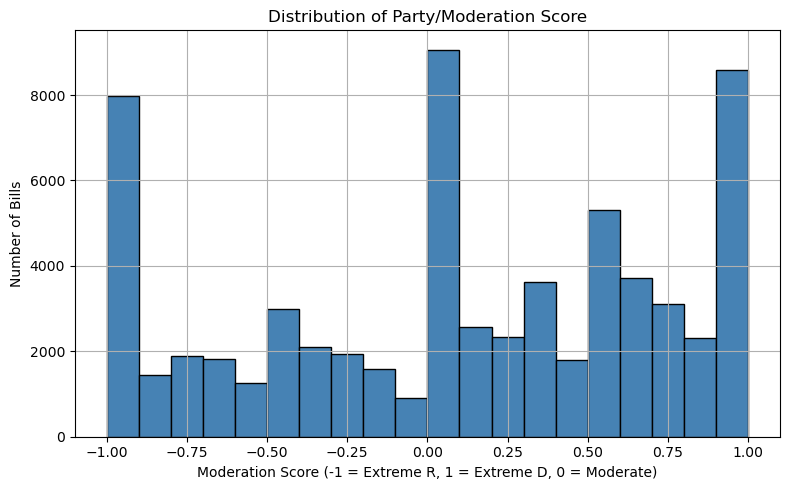

In [35]:
# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(df_bills['extremism_score'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Party/Moderation Score')
plt.xlabel('Moderation Score (-1 = Extreme R, 1 = Extreme D, 0 = Moderate)')
plt.ylabel('Number of Bills')
plt.grid(True)
plt.tight_layout()
plt.show()

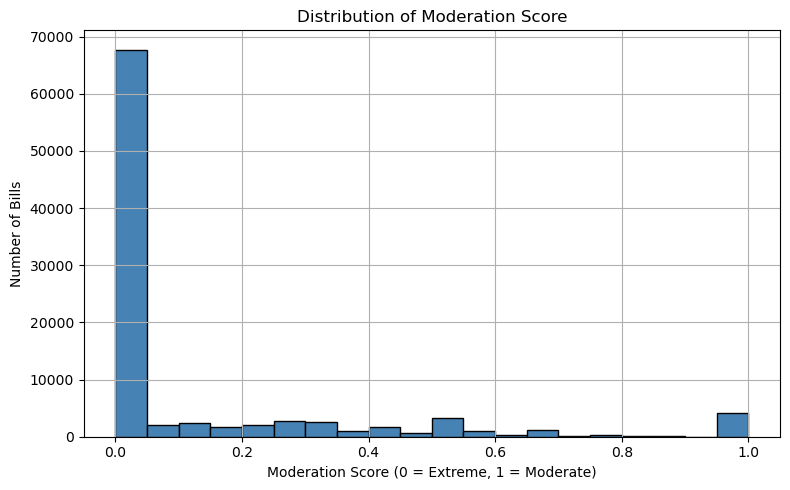

In [36]:
# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(df_bills['moderation_score'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Moderation Score')
plt.xlabel('Moderation Score (0 = Extreme, 1 = Moderate)')
plt.ylabel('Number of Bills')
plt.grid(True)
plt.tight_layout()
plt.show()

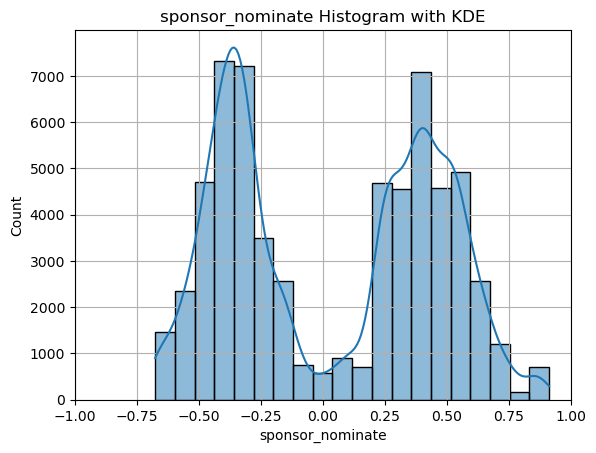

In [66]:
sns.histplot(df_bills['sponsor_nominate'].dropna(), bins=20, kde=True)
plt.title("sponsor_nominate Histogram with KDE")
plt.xlabel("sponsor_nominate")
plt.ylabel("Count")
plt.xlim(-1, 1)
plt.grid(True)
plt.show()


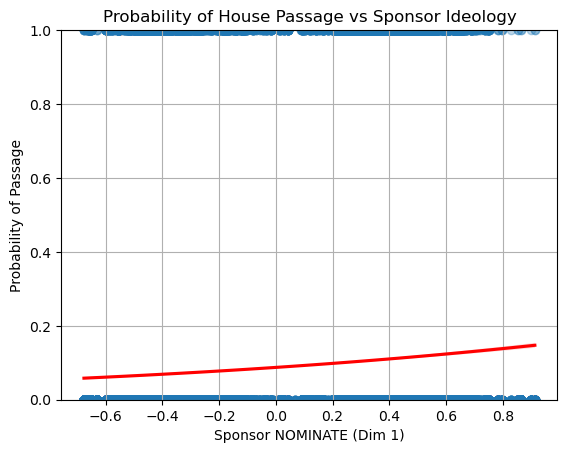

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df_bills,
    x='sponsor_nominate',
    y='house_pass',
    logistic=True,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title("Probability of House Passage vs Sponsor Ideology")
plt.xlabel("Sponsor NOMINATE (Dim 1)")
plt.ylabel("Probability of Passage")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


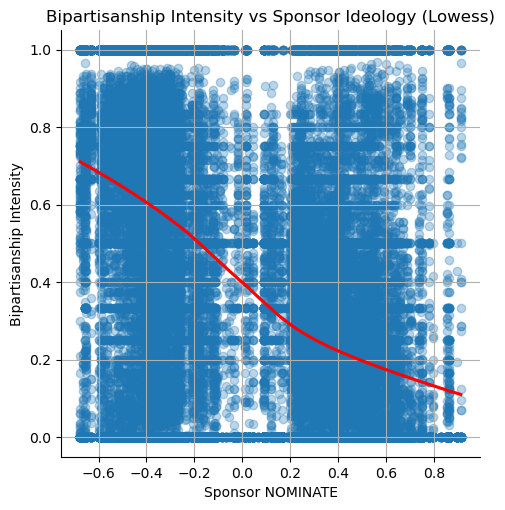

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# sns.scatterplot(
#     data=df_bills,
#     x='sponsor_nominate',
#     y='bipartisanship_intensity',
#     alpha=0.4
# )
# plt.title("Bipartisanship Intensity vs Sponsor Ideology")
# plt.xlabel("Sponsor NOMINATE (Ideology)")
# plt.ylabel("Bipartisanship Intensity")
# plt.grid(True)
# plt.show()

sns.lmplot(
    data=df_bills,
    x='sponsor_nominate',
    y='bipartisanship_intensity',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'},
    lowess=True
)
plt.title("Bipartisanship Intensity vs Sponsor Ideology (Lowess)")
plt.xlabel("Sponsor NOMINATE")
plt.ylabel("Bipartisanship Intensity")
plt.grid(True)
plt.show()


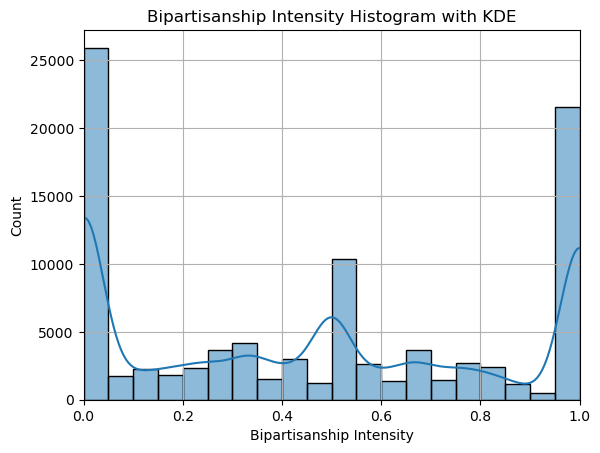

In [19]:
sns.histplot(df_bills['bipartisanship_intensity'].dropna(), bins=20, kde=True)
plt.title("Bipartisanship Intensity Histogram with KDE")
plt.xlabel("Bipartisanship Intensity")
plt.ylabel("Count")
plt.xlim(0, 1)
plt.grid(True)
plt.show()


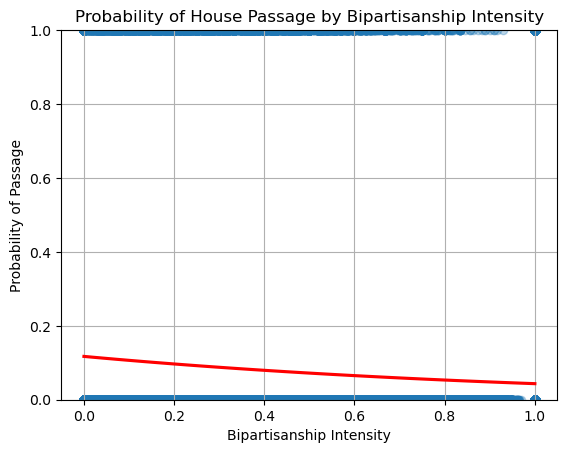

In [11]:
import seaborn as sns

sns.regplot(
    data=df_bills, x='bipartisanship_intensity', y='passed',
    logistic=True, scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}
)
plt.title("Probability of House Passage by Bipartisanship Intensity")
plt.xlabel("Bipartisanship Intensity")
plt.ylabel("Probability of Passage")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


In [11]:
congress_control_df = pd.read_csv(project_path('data','congress_control.csv'), encoding='ISO-8859-1')

# Fix: extract congress number and drop rows where extraction fails (likely due to NaNs or malformed values)
congress_numbers = congress_control_df['congress'].str.extract(r'(\d+)', expand=False)
congress_control_df['congress_number'] = pd.to_numeric(congress_numbers, errors='coerce')

# Drop rows where congress_number is NaN and filter for 104th to 119th
filtered_df = congress_control_df.dropna(subset=['congress_number'])
filtered_df = filtered_df[(filtered_df['congress_number'] >= 104) & (filtered_df['congress_number'] <= 119)].copy()

# Parse start and end years from 'years' column
filtered_df[['start_year', 'end_year']] = filtered_df['years'].str.extract(r'(\d{4})\D+(\d{4})').astype(int)

# Map majority party
filtered_df['majority_party'] = filtered_df['maj_party'].map({'Dem': 'D', 'Rep': 'R'})

# Compute seat margin and scaled gap
filtered_df['seat_margin'] = filtered_df['Seat Diff'].abs()
filtered_df['power_gap_scaled'] = pd.Series(
    pd.Series(filtered_df['seat_margin']).astype(float)
).pipe(lambda x: (x - x.min()) / (x.max() - x.min()) * (0.5 - 0.1) + 0.1)

# Final DataFrame
party_control_ready = filtered_df[[
    'start_year', 'end_year', 'majority_party', 'seat_margin', 'power_gap_scaled','President','Trifecta'
]].reset_index(drop=True)



In [14]:
party_control_ready.to_csv(project_path("data","congress_control.csv"), index=False)